## Data Loading and inspection

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(r'C:\Users\wwwsu\Documents\Customer-Churn-Project-\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
# Identifying target variable distribution
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Churn is more than 20 percent here so it can be assumed to be a realistic retention problem.

### Categorising variables 

In [10]:
demographic = ["gender", "SeniorCitizen", "Partner", "Dependents"]

contractual = ["Contract", "tenure"]

financial = ["MonthlyCharges", "TotalCharges" , "PaperlessBilling", "PaymentMethod"]

behavioral = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [11]:
print("Demographic:", demographic)
print("Contractual:", contractual)
print("Financial:", financial)
print("Behavioral:", behavioral)

Demographic: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
Contractual: ['Contract', 'tenure']
Financial: ['MonthlyCharges', 'TotalCharges', 'PaperlessBilling', 'PaymentMethod']
Behavioral: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


### Data cleaning

In [ ]:
# Converting TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [14]:
# Checking missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

As there are only 11 missing values in TotalCharges, we will drop it 

In [15]:
df = df.dropna()

In [17]:
# Converting target variable to numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [18]:
# Removing ID column
df = df.drop(columns=["customerID"])

As Customer ID doesnot have any behavioral or predictive meaning, so it is dropped.

## Hypothesis 1: Contract vs Churn

First hypothesis states:
* Null hypothesis (H₀): Contract type and churn are independent.

* Alternative hypothesis (H₁): Contract type and churn are associated.

In [19]:
# Computing churn rate by contract
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

In [20]:
contract_churn = df.groupby("Contract")["Churn"].mean()*100
contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Customers without long-term commitment churn 15x more than those on 2-year contracts.

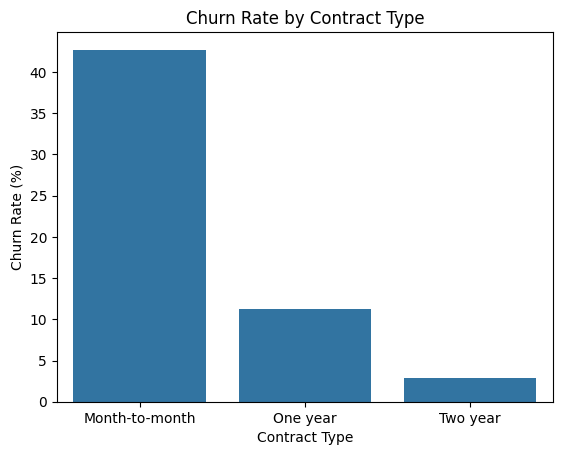

In [21]:
# Visualizing churn rate by contract
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.show()

* Churn rates decline sharply with increasing contract duration.
* Customers on month-to-month contracts exhibit significantly higher attrition risk than those on longer contracts.
* This supports the hypothesis that contractual commitment reduces churn by increasing switching costs and behavioral lock-in.

### Statistical test for Contract vs Churn

In [24]:
from scipy.stats import chi2_contingency

contract_table = pd.crosstab(df["Contract"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(contract_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1179.5458287339445
p-value: 7.326182186265472e-257


In [25]:
if p < 0.05:
    print("Result: Contract type significantly affects churn")
else:
    print("Result: No statistically significant relationship")

Result: Contract type significantly affects churn


#### Conclusion
The chi-square test shows a statistically significant relationship between contract type and churn (p < 0.05). Therefore, we reject the null hypothesis and conclude that contract type influences customer churn. Customers on month-to-month contracts are more likely to churn compared to those on long-term contracts.

### Hypothesis 2: Payment Method vs Churn

Second hypothesis states:
* Null hypothesis (H₀): Payment method and churn are independent.

* Alternative hypothesis (H₁): Payment method and churn are associated.

In [22]:
payment_churn = df.groupby("PaymentMethod")["Churn"].mean()*100
payment_churn.sort_values(ascending=False)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

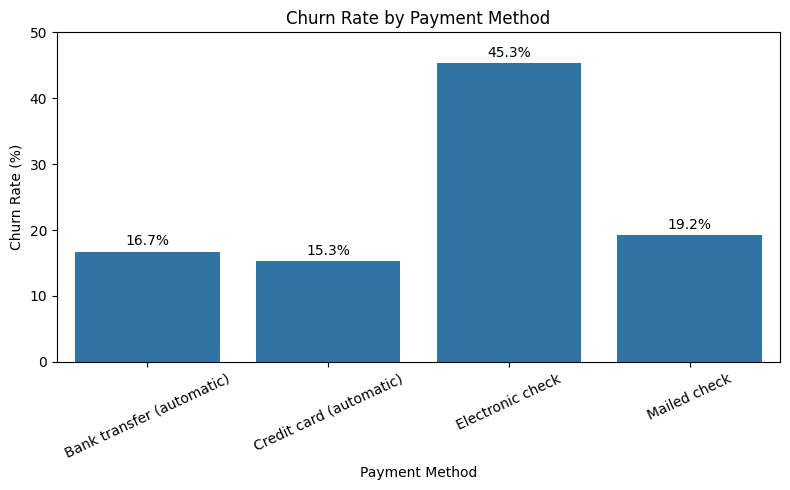

In [23]:
# Visualizing churn rate by payment method
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=25)
plt.ylim(0, 50)

# add value labels on bars
for i, v in enumerate(payment_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

* Customers using manual or semi-manual payment methods, particularly electronic checks, exhibit substantially higher churn rates than those using automated payments.
* This suggests that automated billing creates behavioral lock-in, reducing churn by lowering the cognitive and transactional effort required to remain subscribed.

### Statistical test for Payment Method vs Churn

In [26]:
payment_table = pd.crosstab(df["PaymentMethod"], df["Churn"])

chi2, p, dof, expected = chi2_contingency(payment_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 645.4299001234638
p-value: 1.4263098511063342e-139


In [28]:
if p < 0.05:
    print("Result: Payment method significantly affects churn")
else:
    print("Result: No statistically significant relationship")

Result: Payment method significantly affects churn


#### Conclusion
The chi-square test indicates a statistically significant association between payment method and churn (p < 0.05). Thus, we reject the null hypothesis and conclude that payment method affects churn. Customers using electronic checks show higher churn compared to other payment methods.